In [2]:
import pandas as pd

df = pd.read_csv("data/wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
display(df.describe())

Shape of dataset: (178, 14)

Column names:
Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='str')

Data types:
Type                 int64
Alcohol            float64
Malic              float64
Ash                float64
Alcalinity         float64
Magnesium            int64
Phenols            float64
Flavanoids         float64
Nonflavanoids      float64
Proanthocyanins    float64
Color              float64
Hue                float64
Dilution           float64
Proline              int64
dtype: object

Missing values:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

Basic statistics:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


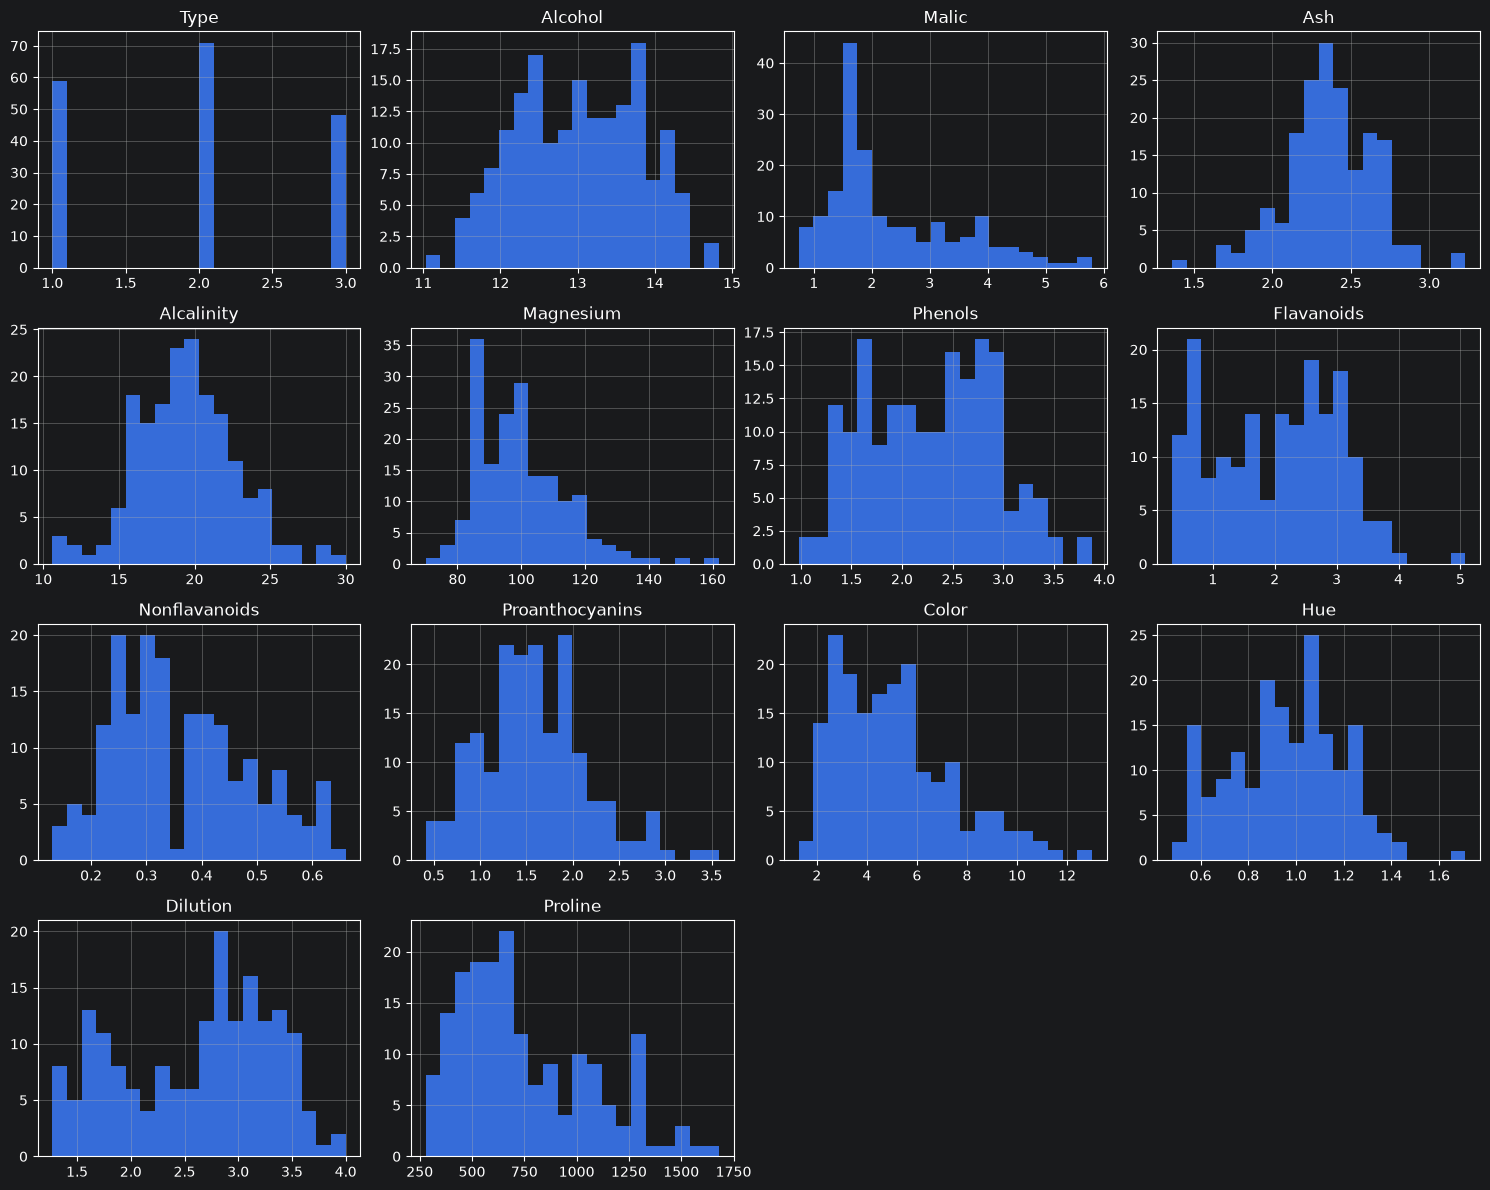

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12), bins=20)

plt.tight_layout()
plt.show()

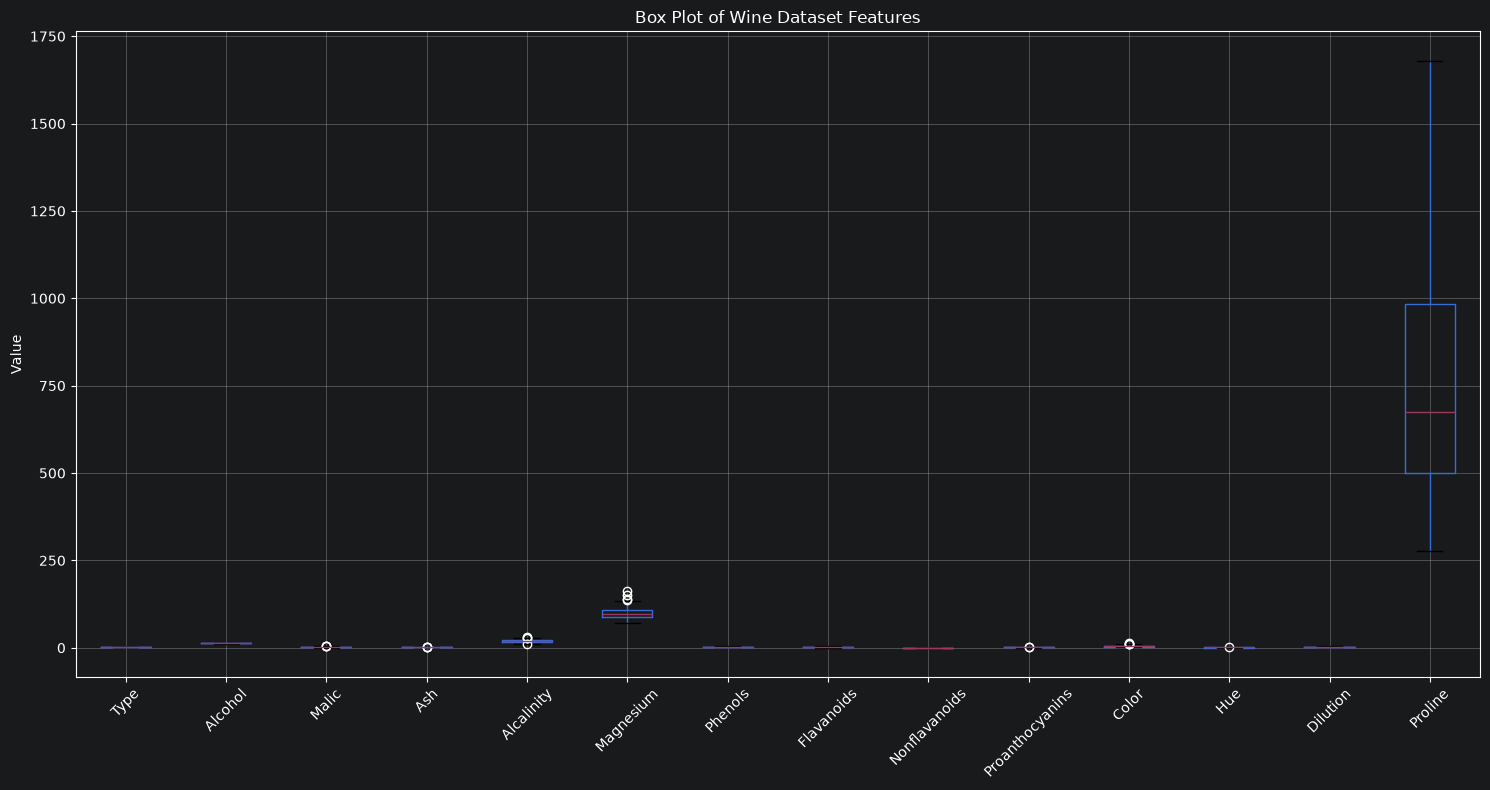

In [5]:
plt.figure(figsize=(15, 8))

df.boxplot()

plt.xticks(rotation=45)
plt.title("Box Plot of Wine Dataset Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

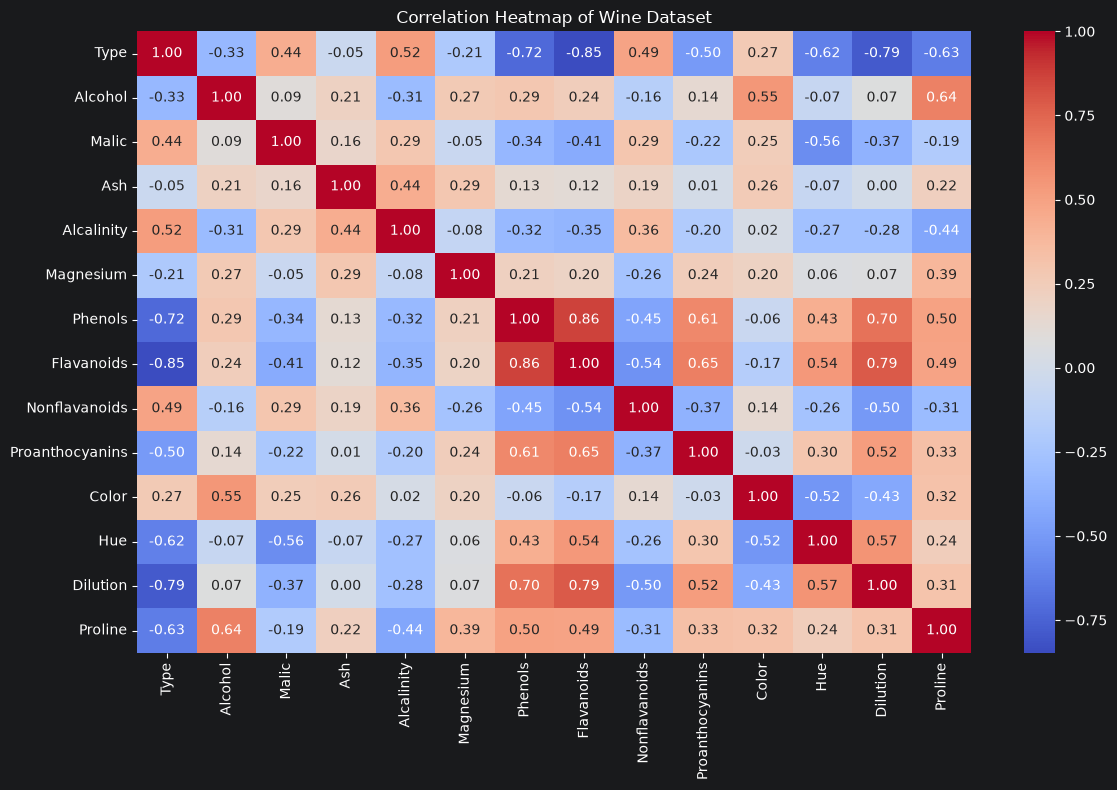

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Wine Dataset")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Standardization completed.")
print("Shape of standardized data:", X_scaled.shape)

Standardization completed.
Shape of standardized data: (178, 14)


In [10]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

PCA completed.
Original shape: (178, 14)
PCA shape: (178, 14)

Explained variance ratio:
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]


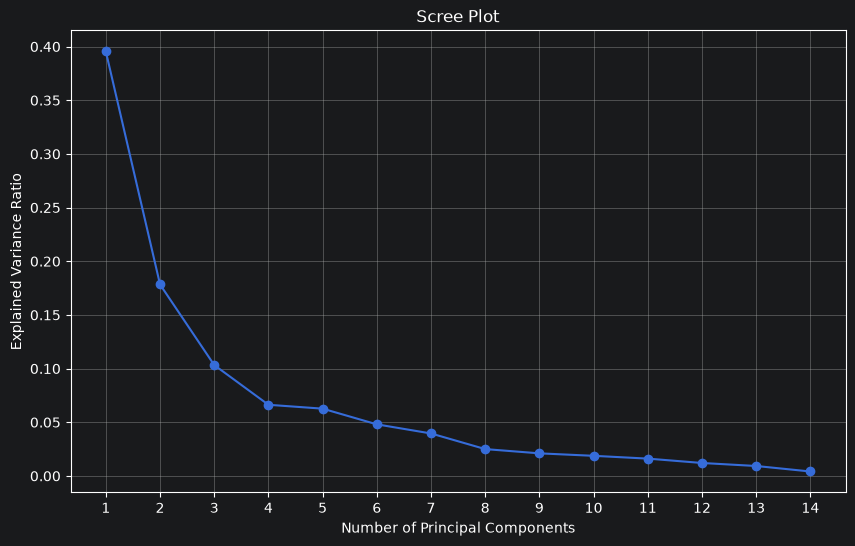

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)

plt.show()

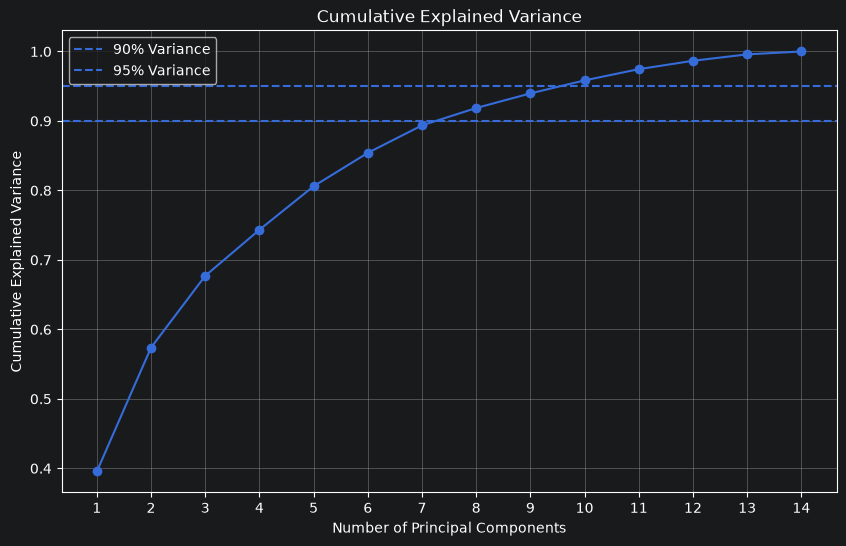

Cumulative explained variance:
[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(y=0.90, linestyle='--', label='90% Variance')
plt.axhline(y=0.95, linestyle='--', label='95% Variance')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.show()

print("Cumulative explained variance:")
print(cumulative_variance)

In [13]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 90% variance:", components_90)
print("Components needed for 95% variance:", components_95)

Components needed for 90% variance: 8
Components needed for 95% variance: 10


In [14]:
# Use the number of components required for 95% variance
n_components = components_95

pca_final = PCA(n_components=n_components)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Number of selected components:", n_components)
print("Original data shape:", df.shape)
print("PCA data shape:", X_pca_final.shape)

Number of selected components: 10
Original data shape: (178, 14)
PCA data shape: (178, 10)


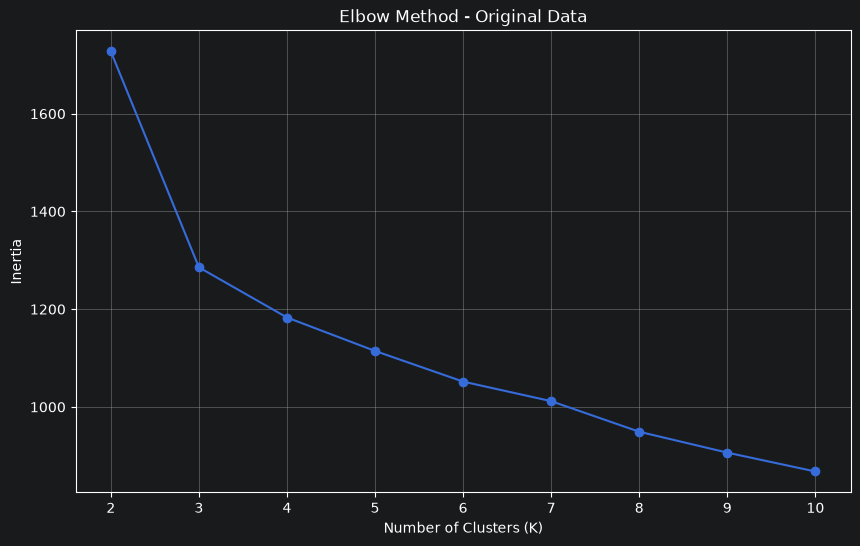

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Original Data")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_original = kmeans_original.fit_predict(X_scaled)

print("K-Means clustering completed.")
print("Number of clusters:", len(set(clusters_original)))

print("\nCluster counts:")
print(pd.Series(clusters_original).value_counts().sort_index())

K-Means clustering completed.
Number of clusters: 3

Cluster counts:
0    61
1    68
2    49
Name: count, dtype: int64


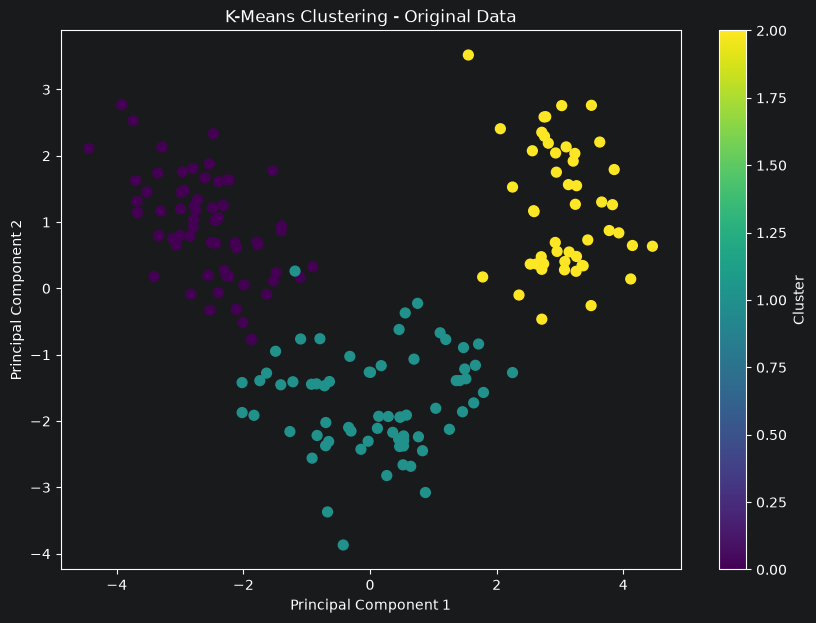

In [17]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_original,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering - Original Data")
plt.colorbar(label="Cluster")

plt.show()

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_original = silhouette_score(
    X_scaled,
    clusters_original
)

davies_bouldin_original = davies_bouldin_score(
    X_scaled,
    clusters_original
)

print("Original Data Clustering Performance")
print("------------------------------------")
print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", davies_bouldin_original)

Original Data Clustering Performance
------------------------------------
Silhouette Score: 0.30773604383565206
Davies-Bouldin Index: 1.3163957434114109


In [19]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca_final)

print("K-Means clustering on PCA data completed.")
print("Number of clusters:", len(set(clusters_pca)))

print("\nCluster counts:")
print(pd.Series(clusters_pca).value_counts().sort_index())

K-Means clustering on PCA data completed.
Number of clusters: 3

Cluster counts:
0    61
1    68
2    49
Name: count, dtype: int64


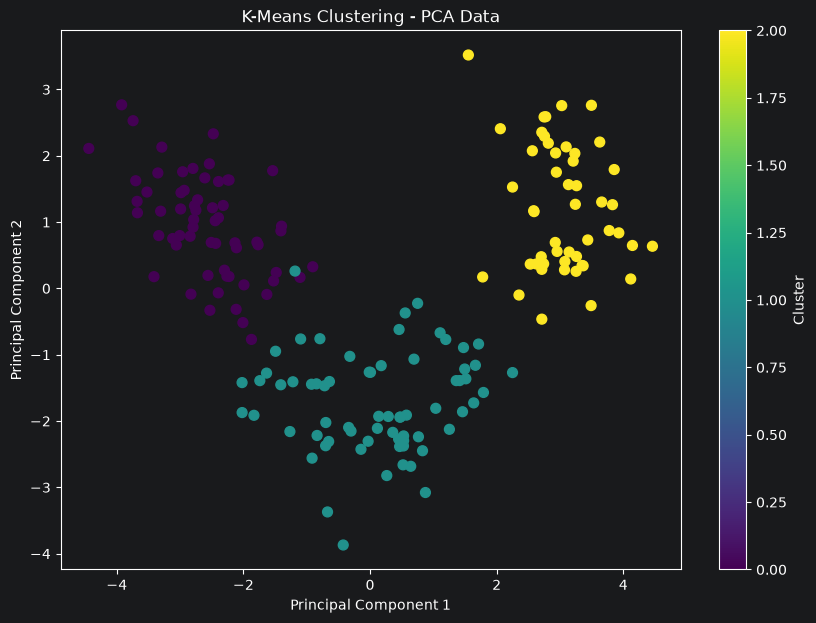

In [20]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_final[:, 0],
    X_pca_final[:, 1],
    c=clusters_pca,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering - PCA Data")
plt.colorbar(label="Cluster")

plt.show()

In [21]:
silhouette_pca = silhouette_score(
    X_pca_final,
    clusters_pca
)

davies_bouldin_pca = davies_bouldin_score(
    X_pca_final,
    clusters_pca
)

print("PCA Data Clustering Performance")
print("--------------------------------")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", davies_bouldin_pca)

PCA Data Clustering Performance
--------------------------------
Silhouette Score: 0.32406582053311866
Davies-Bouldin Index: 1.2584890242254978


In [22]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [
        silhouette_original,
        silhouette_pca
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_original,
        davies_bouldin_pca
    ]
})

comparison

,Method,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.307736,1.316396
1,PCA Data,0.324066,1.258489


In [23]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    clusters_original,
    clusters_pca
)

print("Adjusted Rand Index:", ari_score)

Adjusted Rand Index: 1.0


### Task 5: Comparison and Analysis

K-Means clustering was performed on both the standardized original dataset and the PCA-transformed dataset using 3 clusters. The original dataset produced a Silhouette Score of 0.3077 and a Davies–Bouldin Index of 1.3164. After applying PCA, the Silhouette Score increased to 0.3241, while the Davies–Bouldin Index decreased to 1.2585.

The PCA-based clustering therefore showed a slight improvement in clustering quality. A higher Silhouette Score indicates better separation between clusters, while a lower Davies–Bouldin Index indicates better-defined and more compact clusters.

The Adjusted Rand Index between the original-data and PCA-data cluster assignments was 1.0000. This indicates that the clustering assignments were identical between the two approaches, apart from possible differences in cluster labels.

These results show that PCA successfully reduced the dimensionality while preserving the important clustering structure in the dataset. The main advantage of PCA in this analysis is that it can simplify the feature space and reduce computational complexity without sacrificing clustering performance.

The trade-off is that PCA transforms the original features into principal components, which can make the results less directly interpretable in terms of the original variables. Therefore, PCA is useful when dimensionality reduction, computational efficiency, and visualization are important, while clustering directly on the original standardized data may be preferred when interpretability of the original features is the priority.


### Task 6: Conclusion and Insights

The PCA and clustering analysis was successfully performed on the Wine dataset. Exploratory Data Analysis was first conducted using descriptive statistics, histograms, box plots, and a correlation heatmap to understand the characteristics and relationships among the features.

The features were standardized before applying Principal Component Analysis. PCA was then used to reduce the dimensionality of the dataset while retaining most of the important information. K-Means clustering with 3 clusters was applied to both the standardized original data and the PCA-transformed data.

For the original data, the Silhouette Score was 0.3077 and the Davies–Bouldin Index was 1.3164. For the PCA data, the Silhouette Score improved to 0.3241 and the Davies–Bouldin Index decreased to 1.2585. The Adjusted Rand Index was 1.0000, showing that the cluster assignments from the original and PCA data were identical.

These results demonstrate that PCA preserved the important clustering structure of the dataset while reducing its dimensionality. PCA also produced a slight improvement in the clustering evaluation metrics.

In practical data analysis, PCA can be useful when a dataset contains many features, when dimensionality needs to be reduced, or when visualization of high-dimensional data is required. Clustering can then be applied to the reduced dataset to simplify analysis and potentially improve computational efficiency.

Based on this analysis, PCA is recommended when dimensionality reduction and visualization are important and when the original feature space is complex. Clustering directly on standardized original data can be preferred when maintaining the interpretability of the original features is more important. In this analysis, PCA was particularly effective because it reduced dimensionality without changing the resulting cluster assignments.
